In [1]:
import argparse
import pathlib
import string

from esm import Alphabet, FastaBatchedDataset, ProteinBertModel, pretrained, MSATransformer
import pandas as pd
from tqdm import tqdm

import itertools
from typing import List, Tuple
import numpy as np
import torch
import os
import numpy as np
import pandas as pd
import tqdm.notebook
from scipy.special import softmax

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda:0


In [ ]:
# curl https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t36_3B_UR50D.pt -o esm2_t36_3B_UR50D.pt
# curl https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t48_15B_UR50D.pt -o esm2_t48_15B_UR50D.pt
import argparse

# 1. Allow argparse.Namespace to be unpickled
torch.serialization.add_safe_globals([argparse.Namespace])

# 2. Define path
model_path = "/lustre/scratch126/gengen/projects_v2/alpha-allostery-global/allostery_proteome/00.esm_cache/esm2_t36_3B_UR50D.pt"

# 3. Load locally (this should now work)
model, alphabet = pretrained.load_model_and_alphabet_local(model_path)
batch_converter = alphabet.get_batch_converter()

model.eval()
model.to(DEVICE)
print("ESM-2 Loaded from local file.")

ESM-2 Loaded from local file.


In [ ]:
def get_masked_marginal_scores(sequence, model, alphabet, batch_size=4):
    from torch.nn.functional import log_softmax

    model.eval()
    batch_converter = alphabet.get_batch_converter()
    device = next(model.parameters()).device

    standard_aa = list("ACDEFGHIKLMNPQRSTVWY")
    aa_indices = torch.tensor([alphabet.get_idx(a) for a in standard_aa]).to(device)

    # Tokenize WT once
    data = [("wt", sequence)]
    _, _, wt_tokens = batch_converter(data)
    wt_tokens = wt_tokens.to(device)

    seq_len = len(sequence)

    masked_tokens = []
    for i in range(seq_len):
        tokens = wt_tokens.clone()
        tokens[0, i + 1] = alphabet.mask_idx  # mask at token level
        masked_tokens.append(tokens)

    scores = []

    with torch.no_grad():
        for i in range(0, seq_len, batch_size):
            batch = torch.cat(masked_tokens[i:i+batch_size], dim=0)

            logits = model(batch)["logits"]
            log_probs = log_softmax(logits, dim=-1)

            for j in range(batch.size(0)):
                pos = i + j
                lp = log_probs[j, pos + 1, aa_indices]
                scores.append(lp.cpu().numpy())

    score_matrix = np.vstack(scores)

    final_scores = []
    for k in range(seq_len):
        wt_aa = sequence[k]
        wt_idx = standard_aa.index(wt_aa)
        final_scores.append(score_matrix[k] - score_matrix[k, wt_idx])

    df = pd.DataFrame(final_scores, columns=standard_aa)
    df.insert(0, "WT", list(sequence))
    df.insert(0, "Pos", range(1, seq_len + 1))

    return df

# 1. Define sequence
test_seq = "MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDGFIPKNYIEMKPHPWFFGKIPRAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYFLWVVKFNSLNELVDYHRSTSVSRNQQIFLRDIEQVPQQPTYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVNRNV"

# 2. Run the calculation
# NOTE: batch_size=2 is a safe starting point for the 3B model
df_scores = get_masked_marginal_scores(test_seq, model, alphabet, batch_size=2)

df_scores

,Pos,WT,A,C,D,E,F,G,H,I,...,M,N,P,Q,R,S,T,V,W,Y
0,1,M,-12.522797,-13.126999,-14.785504,-13.165003,-11.670783,-11.793262,-12.672806,-9.958694,...,0.000000,-13.173794,-13.193136,-11.171808,-10.159610,-13.047306,-11.400369,-8.726057,-14.576403,-13.673716
1,2,E,-11.025300,-14.770769,-4.704899,0.000000,-12.881475,-10.835550,-10.762297,-12.398313,...,-12.989288,-10.705524,-13.095495,-6.024018,-11.682593,-11.766421,-12.974595,-10.612818,-13.518578,-12.050856
2,3,A,0.000000,-4.274000,-10.878002,-12.140166,-5.745635,-5.591512,-9.810661,-8.653040,...,-8.501344,-9.586184,-11.774319,-11.767940,-10.791466,-2.764657,-4.845219,-5.314771,-8.373356,-7.644689
3,4,I,-4.133808,-4.383356,-8.062871,-6.103142,-2.791248,-8.201417,-3.380324,0.000000,...,-3.772216,-5.314425,-9.987660,-4.752080,-4.030753,-4.835517,-1.867477,-0.002080,-6.826655,-2.606680
4,5,A,0.000000,-8.311526,-8.059635,-9.382919,-11.745588,-2.790981,-14.135309,-10.431790,...,-11.865062,-11.997845,-9.471081,-14.402628,-10.708941,-5.110640,-6.651922,-6.888664,-12.638721,-13.221134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,V,-0.929757,-2.346301,-6.652252,-6.244215,-2.539731,-4.287088,-4.204641,-1.440955,...,-3.262215,-4.692428,-5.624416,-5.520228,-5.359624,-3.405105,-2.854445,0.000000,-5.919641,-2.415998
213,214,N,-1.170221,-3.282564,-1.973007,-1.884345,-2.591842,-1.260579,-0.323416,-2.335667,...,-2.897274,0.000000,-0.762617,-0.261986,0.278220,-0.217101,-0.316858,-1.576730,-4.031183,-0.469208
214,215,R,-1.906175,-3.246057,-1.983427,-1.340809,-3.047292,-1.093778,-0.951808,-2.876478,...,-3.163564,-0.544390,-0.675805,-0.227407,0.000000,-0.776000,-1.434276,-2.290140,-3.981224,-1.776785
215,216,N,-0.417576,-1.854101,-1.442047,-1.359302,-1.883042,-0.047548,-0.742847,-1.849406,...,-2.000036,0.000000,0.795502,-0.045652,0.674366,0.236451,-0.363126,-1.065307,-3.017037,-1.332575


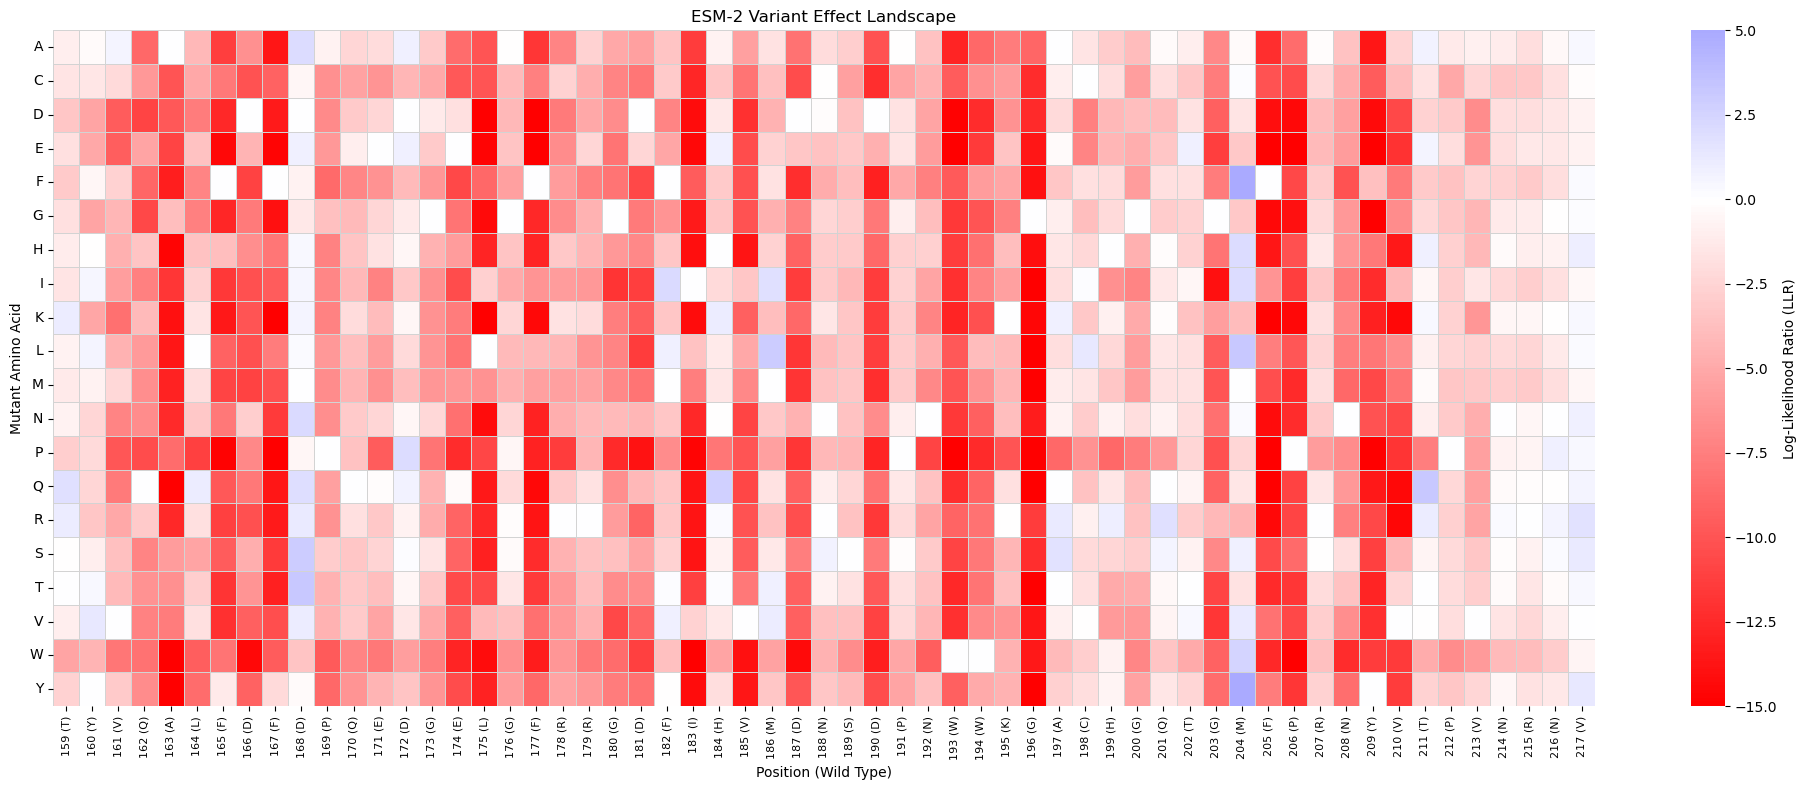

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap(df, start_pos=1, end_pos=None):
    """
    Visualizes the mutation scores as a heatmap.
    Handles removing the text columns 'WT' and 'Pos' automatically.
    """
    # 1. Prepare Data
    plot_df = df.copy()
    
    # Filter by position (optional slicing)
    if end_pos is not None:
        plot_df = plot_df[(plot_df["Pos"] >= start_pos) & (plot_df["Pos"] <= end_pos)]
    
    # Create a nice label for the x-axis: "Position (WildType)" -> e.g., "1 (M)"
    plot_df['Label'] = plot_df['Pos'].astype(str) + " (" + plot_df['WT'] + ")"
    
    # Set this label as the index (so it becomes the x-axis tick labels)
    plot_df = plot_df.set_index('Label')
    
    # Drop the original metadata columns so only numeric scores remain
    # We check if they exist first to avoid errors if run multiple times
    cols_to_drop = [c for c in ['Pos', 'WT'] if c in plot_df.columns]
    heatmap_data = plot_df.drop(columns=cols_to_drop)
    
    # Transpose so Mutations are on Y-axis, Positions on X-axis
    heatmap_data = heatmap_data.T

    # 2. Plotting
    plt.figure(figsize=(20, 8)) 
    
    sns.heatmap(
        heatmap_data, 
        cmap="bwr_r",     # Blue=Good, White=Neutral, Red=Bad
        center=0, 
        vmin=-15,         # Clamp very negative scores to keep colors visible
        vmax=5,
        cbar_kws={'label': 'Log-Likelihood Ratio (LLR)'},
        linewidths=0.5,   # Grid lines make it easier to read
        linecolor='lightgray'
    )
    
    plt.title(f"ESM-2 Variant Effect Landscape")
    plt.xlabel("Position (Wild Type)")
    plt.ylabel("Mutant Amino Acid")
    
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Run the fixed function
plot_heatmap(df_scores, start_pos=159, end_pos=217)

In [5]:
kras = "MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHHYREQIKRVKDSEDVPMVLVGNKCDLPSRTVDTKQAQDLARSYGIPFIETSAKTRQRVEDAFYTLVREIRQYRLKKISKEEKTPGCVKIKKCIIM"

# 2. Run the calculation
# NOTE: batch_size=2 is a safe starting point for the 3B model
df_scores_kras = get_masked_marginal_scores(kras, model, alphabet, batch_size=2)
df_scores_kras.to_csv("/lustre/scratch126/gengen/projects_v2/alpha-allostery-global/allostery_pathogenicity/git_allostery_pathogenicity/data/revision/esm2/kras_esm2_3b_fl.csv", index=False)

In [6]:
src = "MGSNKSKPKDASQRRRSLEPAENVHGAGGGAFPASQTPSKPASADGHRGPSAAFAPAAAEPKLFGGFNSSDTVTSPQRAGPLAGGVTTFVALYDYESRTETDLSFKKGERLQIVNNTEGDWWLAHSLSTGQTGYIPSNYVAPSDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCPTSKPQTQGLAKDAWEIPRESLRLEVKLGQGCFGEVWMGTWNGTTRVAIKTLKPGTMSPEAFLQEAQVMKKLRHEKLVQLYAVVSEEPIYIVTEYMSKGSLLDFLKGETGKYLRLPQLVDMAAQIASGMAYVERMNYVHRDLRAANILVGENLVCKVADFGLARLIEDNEYTARQGAKFPIKWTAPEAALYGRFTIKSDVWSFGILLTELTTKGRVPYPGMVNREVLDQVERGYRMPCPPECPESLHDLMCQCWRKEPEERPTFEYLQAFLEDYFTSTEPQYQPGENL"

# 2. Run the calculation
# NOTE: batch_size=2 is a safe starting point for the 3B model
df_scores_src = get_masked_marginal_scores(src, model, alphabet, batch_size=2)
df_scores_src.to_csv("/lustre/scratch126/gengen/projects_v2/alpha-allostery-global/allostery_pathogenicity/git_allostery_pathogenicity/data/revision/esm2/src_esm2_3b_fl.csv", index=False)

In [ ]:
test_seq = "TYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVN"

# 2. Run the calculation
# NOTE: batch_size=2 is a safe starting point for the 3B model
df_scores2 = get_masked_marginal_scores(test_seq, model, alphabet, batch_size=2)

plot_heatmap(df_scores2)

In [ ]:
df_scores2.to_csv("/lustre/scratch126/gengen/projects_v2/alpha-allostery-global/allostery_pathogenicity/git_allostery_pathogenicity/data/revision/esm2/grb2_sh3_esm2_3b_domain.csv", index=False)

In [ ]:
df_scores.to_csv("/lustre/scratch126/gengen/projects_v2/alpha-allostery-global/allostery_pathogenicity/git_allostery_pathogenicity/data/revision/esm2/grb2_sh3_esm2_3b_fl.csv", index=False)

In [ ]:
df = pd.read_csv("/lustre/scratch126/gengen/projects_v2/alpha-allostery-global/allostery_proteome/git_allostery_proteome-wide/data/esm1v_outs/grb2_sh3_esm1v_mean.csv", index_col=0)  # change path; remove index_col=0 if not needed
df
print(df.columns)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

def plot_esm1v_from_index(df_input):
    # 1. Reset the index to move mutation names (T1A, etc.) into a column
    df = df_input.copy()
    df = df.reset_index()
    
    # After reset_index(), the first column usually gets named 'index' or 'level_0'
    # We rename it to 'mutation' to be safe
    df.rename(columns={df.columns[0]: 'mutation'}, inplace=True)

    print(f"Plotting using column: 'mutation'...")

    # 2. Parse the mutation string (e.g., "T1A")
    def parse_mutation(mut_str):
        mut_str = str(mut_str)
        # Regex: (AminoAcid)(Number)(AminoAcid)
        match = re.match(r"([A-Z])(\d+)([A-Z])", mut_str)
        if match:
            return match.groups()
        return None, None, None

    # Extract WT, Pos, Mutant
    # zip(*...) transposes the list of tuples into 3 separate lists
    parsed = df['mutation'].apply(parse_mutation).tolist()
    df['WT'], df['Pos'], df['Mutant'] = zip(*parsed)
    
    # Drop rows that failed to parse (e.g., if header rows got mixed in)
    df = df.dropna(subset=['Pos'])
    
    # Convert Pos to integer for numerical sorting
    df['Pos'] = df['Pos'].astype(int)

    # 3. Create Pivot Table for Heatmap
    # X-axis Label: "1 (M)"
    df['Label'] = df['Pos'].astype(str) + " (" + df['WT'] + ")"
    
    # Pivot: Index=Mutant, Columns=Label, Values=esm1v_mean
    heatmap_matrix = df.pivot(index='Mutant', columns='Label', values='esm1v_mean')
    
    # 4. Sort Columns Numerically
    # We split "10 (A)" -> 10 to sort correctly
    sorted_cols = sorted(heatmap_matrix.columns, key=lambda x: int(x.split()[0]))
    heatmap_matrix = heatmap_matrix[sorted_cols]
    heatmap_matrix = heatmap_matrix.sort_index()

    # 5. Plot
    plt.figure(figsize=(20, 8))
    sns.heatmap(
        heatmap_matrix, 
        cmap="bwr_r",        # Blue=Favorable, Red=Deleterious
        center=0, 
        vmin=-15, vmax=5,    # Clamping range for better contrast
        cbar_kws={'label': 'ESM-1v Mean (LLR)'},
        linewidths=0.5,
        linecolor='lightgray'
    )
    
    plt.title("ESM-1v Mean Variant Effect Landscape")
    plt.xlabel("Position (Wild Type)")
    plt.ylabel("Mutant Amino Acid")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Run the function
plot_esm1v_from_index(df)

In [ ]:
psd95 = "MDCLCIVTTKKYRYQDEDTPPLEHSPAHLPNQANSPPVIVNTDTLEAPGYELQVNGTEGEMEYEEITLERGNSGLGFSIAGGTDNPHIGDDPSIFITKIIPGGAAAQDGRLRVNDSILFVNEVDVREVTHSAAVEALKEAGSIVRLYVMRRKPPAEKVMEIKLIKGPKGLGFSIAGGVGNQHIPGDNSIYVTKIIEGGAAHKDGRLQIGDKILAVNSVGLEDVMHEDAVAALKNTYDVVYLKVAKPSNAYLSDSYAPPDITTSYSQHLDNEISHSSYLGTDYPTAMTPTSPRRYSPVAKDLLGEEDIPREPRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKGDQILSVNGVDLRNASHEQAAIALKNAGQTVTIIAQYKPEEYSRFEAKIHDLREQLMNSSLGSGTASLRSNPKRGFYIRALFDYDKTKDCGFLSQALSFRFGDVLHVIDASDEEWWQARRVHSDSETDDIGFIPSKRRVERREWSRLKAKDWGSSSGSQGREDSVLSYETVTQMEVHYARPIIILGPTKDRANDDLLSEFPDKFGSCVPHTTRPKREYEIDGRDYHFVSSREKMEKDIQAHKFIEAGQYNSHLYGTSVQSVREVAEQGKHCILDVSANAVRRLQAAHLHPIAIFIRPRSLENVLEINKRITEEQARKAFDRATKLEQEFTECFSAIVEGDSFEEIYHKVKRVIEDLSGPYIWVPARERL"

# 2. Run the calculation
# NOTE: batch_size=2 is a safe starting point for the 3B model
df_scores3 = get_masked_marginal_scores(psd95, model, alphabet, batch_size=2)
df_scores3.to_csv("/lustre/scratch126/gengen/projects_v2/alpha-allostery-global/allostery_pathogenicity/git_allostery_pathogenicity/data/revision/esm2/psd95_esm2_3b_fl.csv", index=False)

In [ ]:
psd95_pdz3 = "PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKGDQILSVNGVDLRNASHEQAAIALKNAGQTVTIIAQYKP"

df_scores4 = get_masked_marginal_scores(psd95_pdz3, model, alphabet, batch_size=2)
df_scores4.to_csv("/lustre/scratch126/gengen/projects_v2/alpha-allostery-global/allostery_pathogenicity/git_allostery_pathogenicity/data/revision/esm2/psd95_pdz3_esm2_3b_fl.csv", index=False)